<a href="https://colab.research.google.com/github/humptybigdump/inprogress/blob/main/05_2_ISE_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**To adapt this notebook to your own needs** and to be able to edit it, please make a copy of your own. This works via "*File*" -> "*Save a copy ..*."


---



In Sect. 2.11 *Naive Bayes Classification* of the ISE 2025 lecture we introduce you to **text categorisation**, which is an important technique of NLP.

**Text fett markieren**#Text Categorisation with Naive Bayes Classification

Naive Bayes models are a group of extremely fast and simple classification algorithms that are often suitable for text categorisation tasks.
Because they are so fast and have so few tunable parameters, they end up being useful as a quick-and-dirty baseline for a classification problem.
This notebook will provide an example of Naive Bayes Classification in action on some datasets.

We begin with the standard imports:

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

#print (plt.style.available)
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

We are using multinomial naive Bayes for text categorisation, where the features are related to word counts or frequencies within the documents to be classified.
We will use the sparse word count features from the **20 Newsgroups corpus** made available through *Scikit-Learn* to show how we might classify these short documents into categories.

Let's download the data and take a look at the target names:

In [ ]:
from sklearn.datasets import fetch_20newsgroups

data = fetch_20newsgroups()
data.target_names

['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

*\[You might uncomment the first 2 lines below and limit the categories to only a few for better readability. If you do this, don't forget to comment out the subsequent category value assignment. \]*

In [ ]:
#limiting the categories to a few
#categories = ['talk.politics.mideast', 'talk.religion.misc',
#              'sci.space', 'alt.atheism','sci.crypt']
categories = data.target_names #use all categories

We load the data into a pandas dataframe just for basic visualisation.

In [ ]:
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
df = pd.DataFrame()
df['text'] = data.data
df['categories'] = [categories[x] for x in data.target]
df.head(10)

,text,categories
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,rec.autos
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,comp.sys.mac.hardware
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,comp.sys.mac.hardware
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,comp.graphics
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,sci.space
5,From: dfo@vttoulu.tko.vtt.fi (Foxvog Douglas)\...,talk.politics.guns
6,From: bmdelane@quads.uchicago.edu (brian manni...,sci.med
7,From: bgrubb@dante.nmsu.edu (GRUBB)\nSubject: ...,comp.sys.ibm.pc.hardware
8,From: holmes7000@iscsvax.uni.edu\nSubject: WIn...,comp.os.ms-windows.misc
9,From: kerr@ux1.cso.uiuc.edu (Stan Kerr)\nSubje...,comp.sys.mac.hardware


In [ ]:
#dimensions of the dataframe
df.values.shape

(11314, 2)

Anyway, we assign now training and test dataset for the text categorisation task. For sake of simplicity, the data has already been prepared for us, so no need for pre-processing and explicit training/test data splitting.

In [ ]:
# The data at scikit-learn has already been prepared and divided into training and test data. We simply assign it accordingly.
train = fetch_20newsgroups(subset='train', categories=categories)
test = fetch_20newsgroups(subset='test', categories=categories)

Here is a random entry from our document corpus:

In [ ]:
print(train.data[3][12:])

@amber (Joe Green)
Subject: Re: Weitek P9000 ?
Organization: Harris Computer Systems Division
Lines: 14
Distribution: world
NNTP-Posting-Host: amber.ssd.csd.harris.com
X-Newsreader: TIN [version 1.1 PL9]

Robert J.C. Kyanko (rob@rjck.UUCP) wrote:
> abraxis@iastate.edu writes in article <abraxis.734340159@class1.iastate.edu>:
> > Anyone know about the Weitek P9000 graphics chip?
> As far as the low-level stuff goes, it looks pretty nice.  It's got this
> quadrilateral fill command that requires just the four points.

Do you have Weitek's address/phone number?  I'd like to get some information
about this chip.

--
Joe Green				Harris Corporation
jgreen@csd.harris.com			Computer Systems Division
"The only thing that really scares me is a person with no sense of humor."
						-- Jonathan Winters



In order to use this data for machine learning, we need to be able to convert the content of each string into a vector of numbers.
For this we will use the TF-IDF vectoriser (introduced in [WordVectors-BagOfWords-TFIDF](https://colab.research.google.com/drive/1Bc8hzWs7LCxk1GBa8Fc_nFBw_jqfUNOf?usp=sharing)), and create a pipeline that attaches it to a multinomial naive Bayes classifier:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline

model = make_pipeline(TfidfVectorizer(), MultinomialNB())

With this pipeline, we can apply the model to the training data and predict labels for the test data:

In [ ]:
model.fit(train.data, train.target)
labels = model.predict(test.data)

Now that we have predicted the labels for the test data, we can evaluate them to learn about the performance of the estimator.
For example, let's take a look at the **confusion matrix** between the true and predicted labels for the test data:

Accuracy:  0.7738980350504514
Recall:  0.756525006352595
Precision:  0.8255310124210137
F1-Measure:  0.7557542971333199


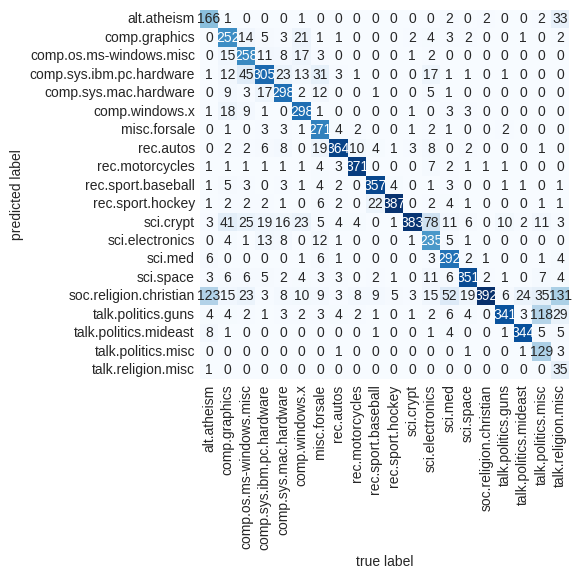

In [ ]:
# import different metrics to evaluate the classifiers
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mat = confusion_matrix(test.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=train.target_names, yticklabels=train.target_names,
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label');

# Print accuracy, Recall, Precision, F1:
print("Accuracy: ", accuracy_score(test.target, labels))
print("Recall: ", recall_score(test.target, labels, average='macro'))
print("Precision: ", precision_score(test.target, labels, average='macro'))
print("F1-Measure: ", f1_score(test.target, labels, average='macro'))

Evidently, even this very simple classifier can successfully **separate middleeast discussions from space** discussions, but it gets confused between discussions about **atheism** and discussions about **religion** or discussions about **religion** and **christianity**.

Even better, we can determine the category for *any* string, using the `predict` method of this pipeline.
Here's a utility function that will return the prediction for a single string:

In [ ]:
def predict_category(s, train=train, model=model):
    pred = model.predict([s])
    return train.target_names[pred[0]]

Let's try it out:

In [ ]:
predict_category('Houston, a subspace anomaly is shutting down the warp core')

'sci.space'

In [ ]:
predict_category('There is a roadblock near Gaza city')

'talk.politics.mideast'

In [ ]:
predict_category('faith will not save us from climate change')

'soc.religion.christian'

In [ ]:
predict_category('my hovercraft is full of eels')

'rec.motorcycles'

Naive Bayes classification is nothing but a simple probability model for the (weighted) frequency of each word in the string; nevertheless, the result seems promising.

## When to Use Naive Bayes

Naive Bayes classifier is often a good choice as an initial baseline classification. However, as naive Bayes classifiers make rather stringent assumptions about data, they will generally not perform as well as more sophisticated machine learning models.

Advantages of Naive Bayesdvantages:

- fast for both training and prediction
- often easily interpretable.
- only a few (if any) tunable parameters.




#Some Take Aways



*   Using Bayes' rule, a classifier can be made by assuming all observed features are independent.
*   Naive Bayes classifier (for text categorisation) can be trained on a dataset by counting the number of occurrences of combinations of labels.
*   Naive Bayes classifier was the gold standard for decades for tasks such as spam detection.